# gwmg: testing gravity with gravitational-wave standard sirens

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/APersonalVoyage/gwmg/blob/main/notebooks/getting_started.ipynb)

Does General Relativity hold on cosmological scales? In modified gravity, gravitational
waves lose amplitude as they travel, so a merger looks *further away* in gravitational
waves than the same event looks in light. Comparing the two distances tests the theory.

This notebook uses the real GW170817 and GW190521 measurements to constrain the
Planck-mass run rate $\alpha_M$, which controls that effect. It needs only
`numpy` and `scipy`, so it runs anywhere in under a minute.

## Install

In [1]:
# Installs gwmg if it is not already present (e.g. on a fresh Colab session).
try:
    import gwmg
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "git+https://github.com/APersonalVoyage/gwmg.git"])
    import gwmg

print("gwmg", gwmg.__version__)

gwmg 0.1.0


## The data

Two events with independently known redshifts. GW170817 is a neutron-star merger with
an electromagnetic counterpart in NGC 4993; GW190521 is a black-hole merger with a
candidate counterpart. `sigma_dgw` is the uncertainty on the gravitational-wave
distance, which is large for GW190521.

In [2]:
import os
import numpy as np
from gwmg import gw_log_likelihood, load_events, pipeline_dir

path = os.path.join(pipeline_dir(), "data", "gw", "ligo_data.txt")
d_gw_obs, z_obs, sigma_dgw, sigma_z, v_rms = load_events(path)

print(f"{'d_GW [Mpc]':>12} {'z':>8} {'sigma_d [Mpc]':>14}")
for d, z, s in zip(d_gw_obs, z_obs, sigma_dgw):
    print(f"{d:12.1f} {z:8.4f} {s:14.1f}")

  d_GW [Mpc]        z  sigma_d [Mpc]
        40.0   0.0099           11.0
      5300.0   0.4380         2500.0


## The model

For a flat $\Lambda$CDM background the distances are a simple integral. The modified
gravity enters only through the ratio

$$\frac{d_L^{\rm GW}(z)}{d_L^{\rm EM}(z)} = \exp\left[\frac{1}{2}\int_0^z \frac{\alpha_M(z')}{1+z'}\,dz'\right]$$

with $\alpha_M(z) = \alpha_{M0}\,\Omega_{\rm DE}(z)$ in the `propto_omega`
parametrisation. $\alpha_{M0} = 0$ is General Relativity.

In [3]:
from scipy.integrate import cumulative_trapezoid

C_KM_S = 299792.458
H0, OMEGA_M = 67.4, 0.315          # fixed background for this notebook

z = np.linspace(0.0, 1.0, 2000)
E = np.sqrt(OMEGA_M * (1 + z) ** 3 + (1 - OMEGA_M))
d_c = (C_KM_S / H0) * cumulative_trapezoid(1.0 / E, z, initial=0.0)
d_l = d_c * (1 + z)                # luminosity distance [Mpc]
h_z = H0 * E / C_KM_S              # H(z)/c [1/Mpc]

def dgw_ratio(alpha_M0):
    alpha_M = alpha_M0 * (1 - OMEGA_M) / E ** 2
    return np.exp(0.5 * cumulative_trapezoid(alpha_M / (1 + z), z, initial=0.0))

for a in (0.0, 1.0, 3.0):
    print(f"alpha_M0 = {a:3.1f}  ->  d_GW/d_EM at z=1 is {np.interp(1.0, z, dgw_ratio(a)):.3f}")

alpha_M0 = 0.0  ->  d_GW/d_EM at z=1 is 1.000
alpha_M0 = 1.0  ->  d_GW/d_EM at z=1 is 1.165
alpha_M0 = 3.0  ->  d_GW/d_EM at z=1 is 1.580


## The likelihood

`gw_log_likelihood` compares the predicted gravitational-wave distances to the measured
ones. It returns $-\chi^2/2$: higher is a better fit. It includes the lensing and
peculiar-velocity contributions to the distance uncertainty, following Baker & Harrison
(2020).

In [4]:
events = dict(d_gw_obs=d_gw_obs, z_obs=z_obs, sigma_dgw=sigma_dgw,
              sigma_z=sigma_z, v_rms=v_rms)

for a in (0.0, 1.0, 3.0):
    print(f"alpha_M0 = {a:3.1f}  ->  log-likelihood {gw_log_likelihood(z, d_l, h_z, dgw_ratio(a), **events):8.3f}")

alpha_M0 = 0.0  ->  log-likelihood   -0.680
alpha_M0 = 1.0  ->  log-likelihood   -0.571
alpha_M0 = 3.0  ->  log-likelihood   -0.358


## Scanning the parameter

The full pipeline explores eight parameters with MCMC. Here there is only one, so a grid
scan is enough. Evaluating the likelihood across the grid and exponentiating gives the
posterior for a flat prior.

In [5]:
grid = np.linspace(-2.0, 6.0, 400)
logL = np.array([gw_log_likelihood(z, d_l, h_z, dgw_ratio(a), **events) for a in grid])

post = np.exp(logL - logL.max())
trapz = getattr(np, "trapezoid", np.trapz)     # np.trapz was removed in numpy 2
post /= trapz(post, grid)

mean = trapz(grid * post, grid)
std = np.sqrt(trapz(grid ** 2 * post, grid) - mean ** 2)
cdf = np.concatenate([[0], np.cumsum(0.5 * (post[1:] + post[:-1]) * np.diff(grid))])
lo, hi = np.interp([0.16, 0.84], cdf / cdf[-1], grid)

print(f"alpha_M0 = {mean:.2f} +/- {std:.2f}")
print(f"68% interval: {lo:.2f} to {hi:.2f}")
print("General Relativity is", "consistent" if lo <= 0 <= hi else "disfavoured", "at 68%")

alpha_M0 = 2.53 +/- 2.26
68% interval: -0.19 to 5.05
General Relativity is consistent at 68%


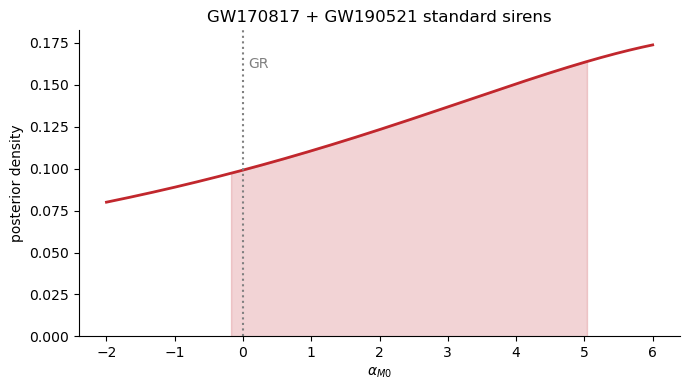

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, post, lw=2, color="#c1272d")
ax.fill_between(grid, 0, post, where=(grid >= lo) & (grid <= hi), alpha=0.2, color="#c1272d")
ax.axvline(0, ls=":", c="grey")
ax.text(0.08, 0.92 * post.max(), "GR", color="grey")
ax.set_xlabel(r"$\alpha_{M0}$")
ax.set_ylabel("posterior density")
ax.set_title("GW170817 + GW190521 standard sirens")
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Where this goes next

The constraint above is weak, and the posterior keeps rising towards the edge of the
scan: two sirens alone barely pin $\alpha_M$ down. The full pipeline adds Planck CMB,
redshift-space distortion and BAO data, and samples the six standard cosmological
parameters alongside $\alpha_{M0}$ and the braiding $\alpha_{B0}$. That tightens it to

$$\alpha_{M0} = 0.4 \pm 0.8, \qquad \alpha_{B0} = 1.0 \pm 0.4$$

still consistent with General Relativity.

That analysis calls `hi_class` at every step, so it takes days. gwmg ships neural-network
emulators that reduce it to about ten minutes:

```bash
gwmg run gw_lss_emulated
```

Those need `cosmopower`, which pins older TensorFlow and numpy, so they are best used in
the conda environment described in the README rather than on Colab.

```python
from gwmg.emulator import Emulator
emu = Emulator()          # trained models ship with the package
out = emu.predict(omega_m=0.315, h0=0.674, omega_b=0.049, n_s=0.965,
                  A_s=2.1e-9, tau=0.054, alpha_B0=1.0, alpha_M0=0.5)
```

- Repository: https://github.com/APersonalVoyage/gwmg
- Method: [Baker & Harrison (2020)](https://arxiv.org/abs/2007.13791)
- Emulators: [CosmoPower](https://arxiv.org/abs/2106.03846)